# Lựa chọn đặc trưng theo mô hình (Model-based)

Notebook này dùng nhiều mô hình để đo mức quan trọng của đặc trưng và tạo bảng xếp hạng tổng hợp.

## 1. Import thư viện

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
np.random.seed(42)

## 2. Nạp dữ liệu

In [ ]:
đường_dẫn_ứng_viên = [
    Path("../../data/raw/abalone.csv"),
    Path("../data/raw/abalone.csv"),
    Path("data/raw/abalone.csv"),
    Path("AbaloneAge/data/raw/abalone.csv"),
]

đường_dẫn_dữ_liệu = None
for p in đường_dẫn_ứng_viên:
    p_đầy_đủ = p.resolve()
    if p_đầy_đủ.exists():
        đường_dẫn_dữ_liệu = p_đầy_đủ
        break

if đường_dẫn_dữ_liệu is None:
    raise FileNotFoundError(
        "Không tìm thấy file abalone.csv. Đã thử: "
        + ", ".join(str(p.resolve()) for p in đường_dẫn_ứng_viên)
    )

df = pd.read_csv(đường_dẫn_dữ_liệu, header=None)
df.columns = [
    "sex",
    "length",
    "diameter",
    "height",
    "whole_weight",
    "shucked_weight",
    "viscera_weight",
    "shell_weight",
    "rings",
]

print("Đường dẫn dữ liệu:", đường_dẫn_dữ_liệu)
print("Kích thước:", df.shape)
df.head()

Duong dan du lieu: C:\Users\Admin\Documents\GitHub\TNTT_Repo_Abalone6\AbaloneAge\data\raw\abalone.csv
Kich thuoc: (4177, 9)


,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


## 3. Chia train, validation, test

In [3]:
X = df.drop(columns=["rings"])
y = df["rings"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (2923, 8) (2923,)
Validation: (627, 8) (627,)
Test: (627, 8) (627,)


## 4. Tiền xử lý bằng Pipeline

In [ ]:
cột_số = [
    "length",
    "diameter",
    "height",
    "whole_weight",
    "shucked_weight",
    "viscera_weight",
    "shell_weight",
]
cột_hạng_mục = ["sex"]

biến_đổi_số = Pipeline(steps=[
    ("dien_khuyet", SimpleImputer(strategy="median")),
    ("chuan_hoa", StandardScaler()),
])

biến_đổi_hạng_mục = Pipeline(steps=[
    ("dien_khuyet", SimpleImputer(strategy="most_frequent")),
    ("one_hot", OneHotEncoder(handle_unknown="ignore")),
])

tiền_xử_lý = ColumnTransformer(transformers=[
    ("so", biến_đổi_số, cột_số),
    ("hang_muc", biến_đổi_hạng_mục, cột_hạng_mục),
])

X_train_txl = tiền_xử_lý.fit_transform(X_train)
X_val_txl = tiền_xử_lý.transform(X_val)
X_test_txl = tiền_xử_lý.transform(X_test)

tên_đặc_trưng = tiền_xử_lý.get_feature_names_out()
print("Số đặc trưng sau tiền xử lý:", len(tên_đặc_trưng))

So dac trung sau tien xu ly: 10


## 5. Huấn luyện các mô hình và lấy độ quan trọng

In [ ]:
mô_hình_dict = {
    "random_forest": RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1),
    "extra_trees": ExtraTreesRegressor(n_estimators=400, random_state=42, n_jobs=-1),
    "ridge": Ridge(alpha=1.0),
}

kết_quả_metric = []
tất_cả_importance = []

for tên_mô_hình, mô_hình in mô_hình_dict.items():
    mô_hình.fit(X_train_txl, y_train)
    dự_đoán_val = mô_hình.predict(X_val_txl)

    mae = mean_absolute_error(y_val, dự_đoán_val)
    rmse = np.sqrt(mean_squared_error(y_val, dự_đoán_val))
    r2 = r2_score(y_val, dự_đoán_val)

    kết_quả_metric.append({
        "mô_hình": tên_mô_hình,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    })

    if hasattr(mô_hình, "feature_importances_"):
        importance = mô_hình.feature_importances_
    else:
        importance = np.abs(mô_hình.coef_)

    bảng_importance = pd.DataFrame({
        "đặc_trưng": tên_đặc_trưng,
        "importance": importance,
        "mô_hình": tên_mô_hình,
    })
    tất_cả_importance.append(bảng_importance)

bảng_metric = pd.DataFrame(kết_quả_metric).sort_values(by="RMSE")
bảng_metric

,mo_hinh,MAE,RMSE,R2
2,ridge,1.620732,2.224273,0.506883
0,random_forest,1.594844,2.269166,0.486777
1,extra_trees,1.611240,2.289981,0.477318


## 6. Tổng hợp xếp hạng đặc trưng

In [ ]:
bảng_all = pd.concat(tất_cả_importance, ignore_index=True)

# Chuẩn hóa importance theo từng mô hình để so sánh công bằng
bảng_all["importance_chuan_hoa"] = bảng_all.groupby("mô_hình")["importance"].transform(
    lambda x: x / (x.max() + 1e-12)
)

bảng_tổng_hợp = (
    bảng_all.groupby("đặc_trưng")["importance_chuan_hoa"]
    .mean()
    .reset_index()
    .rename(columns={"importance_chuan_hoa": "điểm_trung_bình"})
    .sort_values(by="điểm_trung_bình", ascending=False)
)

bảng_tổng_hợp.head(15)

,dac_trung,diem_trung_binh
6,so__shell_weight,0.753377
7,so__shucked_weight,0.620068
9,so__whole_weight,0.536496
3,so__diameter,0.251245
8,so__viscera_weight,0.240857
4,so__height,0.193210
5,so__length,0.166880
1,hang_muc__sex_I,0.137561
2,hang_muc__sex_M,0.042479
0,hang_muc__sex_F,0.036070


## 7. Biểu đồ top đặc trưng

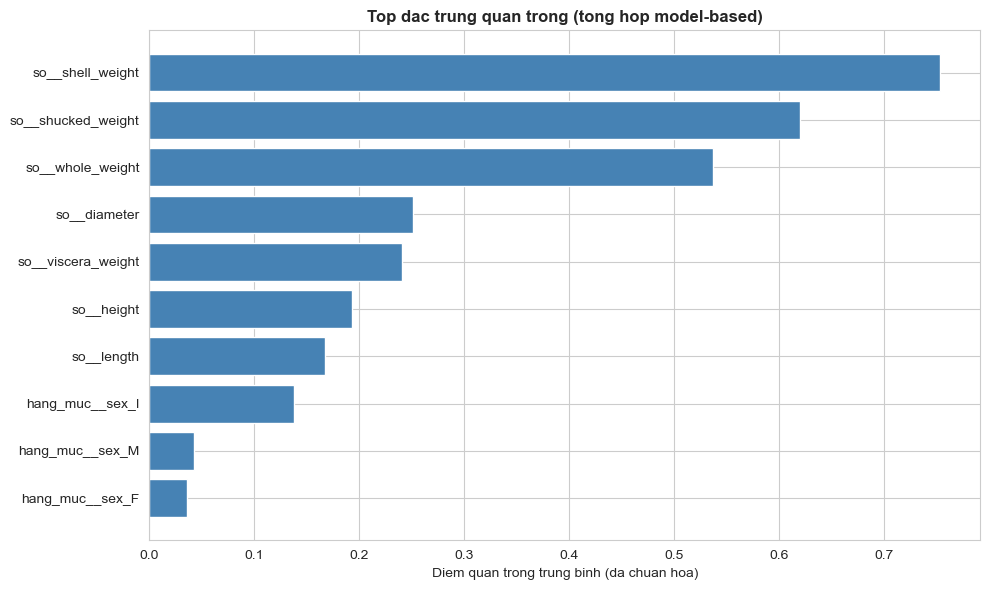

Da luu hinh: 03_feature_selection_model_based_top_features.png


In [ ]:
top_n = 12
bảng_top = bảng_tổng_hợp.head(top_n).sort_values(by="điểm_trung_bình")

plt.figure(figsize=(10, 6))
plt.barh(bảng_top["đặc_trưng"], bảng_top["điểm_trung_bình"], color="steelblue")
plt.title("Top đặc trưng quan trọng (tổng hợp model-based)", fontweight="bold")
plt.xlabel("Điểm quan trọng trung bình (đã chuẩn hóa)")
plt.tight_layout()

đường_dẫn_hình = Path("../../outputs/figures").resolve()
đường_dẫn_hình.mkdir(parents=True, exist_ok=True)
plt.savefig(đường_dẫn_hình / "03_feature_selection_model_based_top_features.png", dpi=300, bbox_inches="tight")
plt.show()

print("Đã lưu hình: 03_feature_selection_model_based_top_features.png")

## 8. Đánh giá mô hình tốt nhất trên test

In [ ]:
mô_hình_tốt_nhất = bảng_metric.iloc[0]["mô_hình"]
model = mô_hình_dict[mô_hình_tốt_nhất]

dự_đoán_test = model.predict(X_test_txl)
mae_test = mean_absolute_error(y_test, dự_đoán_test)
rmse_test = np.sqrt(mean_squared_error(y_test, dự_đoán_test))
r2_test = r2_score(y_test, dự_đoán_test)

print("Mô hình tốt nhất trên validation:", mô_hình_tốt_nhất)
print(f"MAE test : {mae_test:.4f}")
print(f"RMSE test: {rmse_test:.4f}")
print(f"R2 test  : {r2_test:.4f}")

Mo hinh tot nhat tren validation: ridge
MAE test : 1.5451
RMSE test: 2.1457
R2 test  : 0.5515


## 9. Lưu kết quả

In [ ]:
đường_dẫn_metrics = Path("../../outputs/metrics").resolve()
đường_dẫn_metrics.mkdir(parents=True, exist_ok=True)

bảng_metric.to_csv(đường_dẫn_metrics / "03_model_based_model_metrics.csv", index=False)
bảng_all.to_csv(đường_dẫn_metrics / "03_model_based_all_importance.csv", index=False)
bảng_tổng_hợp.to_csv(đường_dẫn_metrics / "03_model_based_feature_ranking.csv", index=False)

tóm_tắt = {
    "phương_pháp": "model_based",
    "mô_hình_tốt_nhất": mô_hình_tốt_nhất,
    "test": {
        "MAE": mae_test,
        "RMSE": rmse_test,
        "R2": r2_test,
    },
    "top_10": bảng_tổng_hợp.head(10).to_dict(orient="records"),
}

with open(đường_dẫn_metrics / "03_model_based_summary.json", "w", encoding="utf-8") as f:
    json.dump(tóm_tắt, f, ensure_ascii=False, indent=2)

print("Đã lưu: 03_model_based_model_metrics.csv")
print("Đã lưu: 03_model_based_all_importance.csv")
print("Đã lưu: 03_model_based_feature_ranking.csv")
print("Đã lưu: 03_model_based_summary.json")

Da luu: 03_model_based_model_metrics.csv
Da luu: 03_model_based_all_importance.csv
Da luu: 03_model_based_feature_ranking.csv
Da luu: 03_model_based_summary.json
